# TV under-reach, Social over-saturation: `coefficient` prior, lower target ROI

**Objective.** `tv-test-under-simple-dgp-coefficient-prior.ipynb` found that
switching `media_prior_type` from `'roi'` to `'coefficient'` does not fix the
TV `roi_m` flip seen in `tv-test-under-simple-dgp.ipynb`: correctly informing
`ec_m` (`ec_only`/`ec_alpha_only`, within ~1.5% of the true 13.32) still left
`roi_m[TV]` biased ~26% low (~5.9 vs true 8.0), essentially unchanged from
the `'roi'`-parameterized result (~5.8). That notebook also found
`'coefficient'` broke MCMC convergence for `default`'s `ec_m[Display]`/
`roi_m[Display]` (`r_hat` 1.42, ESS bulk 4-5).

This notebook re-runs the identical `'coefficient'`-parameterized scenario
and the same `default`/`ec_only`/`ec_alpha_only` variants, changing only
`target_roi` from `{'TV': 8.0, 'Display': 5.0, 'Social': 3.0}` to
`{'TV': 3.0, 'Display': 2.0, 'Social': 1.0}` -- to see whether the TV
`roi_m` bias (and the Display convergence failure) is a function of the
absolute ROI/effect-scale magnitude the simulator is calibrated to, rather
than something specific to the `ec_m`/reach/frequency story. Everything else
(audience sizes, reach/frequency targets, noise settings, prior variants,
MCMC settings) is unchanged from the coefficient-prior notebook.

**How to read this notebook:**
- Section 1 builds the same simplified scenario, now calibrated to the lower
  target ROI, and reports the resulting true `ec_m`/ceiling-fraction/
  `roi_m` (note: `ec_m` is a function of audience/reach/frequency, not of
  `target_roi`, so the true `ec_m` values should be identical to the
  higher-ROI notebooks; only true `roi_m` changes).
- Section 2 fits `default`, `ec_only`, and `ec_alpha_only` with
  `media_prior_type='coefficient'` and reports the same `alpha_m`/`ec_m`/
  `roi_m` headline diagnostics, for comparison against the higher-target-ROI
  results above.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from meridian.analysis import optimizer
from meridian.model import adstock_hill
from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_model_spec
from model_utils import build_simulated_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import hill_value
from model_utils import posterior_param_mean
from model_utils import roi_posterior_summary

## 1. The identical simplified TV under-reach / Social over-saturation scenario

Same scenario as `tv-test-under-simple-dgp.ipynb` -- TV: large target
audience, low reach (~10%), low frequency (1.5/week); Display: moderate;
Social: high reach (90%), high frequency (7/week), deliberately
over-saturated -- with every stochastic *texture* layer on top of that flat
reach/frequency target turned off via the same `SimulationConfig`
overrides. See that notebook for the full rationale; nothing about the
scenario changes here, only `media_prior_type` in Section 2.

ec_m = [14.358664    1.1171008   0.28679755]


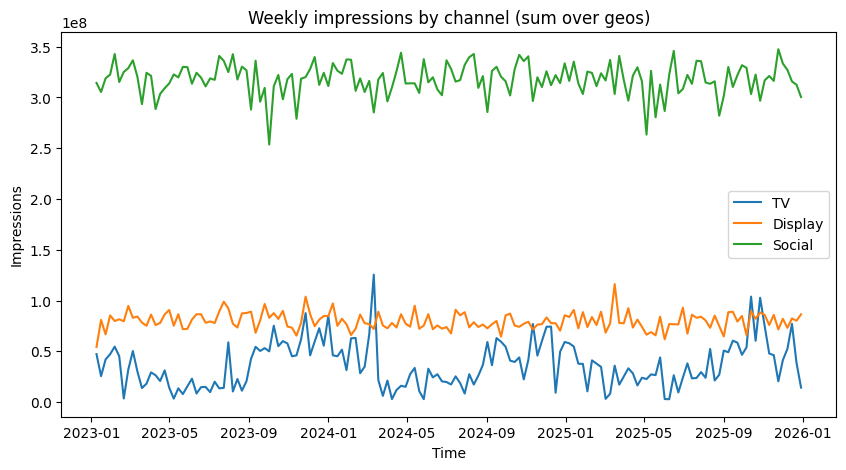

In [8]:
SIMPLE_CONFIG_OVERRIDES = {
    # Same story as `tv-test-under-simple-dgp.ipynb`.
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        # Point ranges (low == high) -- flat frequency, no per-geo-time
        # spread, so "frequency" is a single clean number per channel.
        'TV': (1, 2),
        'Display': (3, 5),
        'Social': (7.0, 8.0),
    },
    'adstock_retention_range': {
      'TV': (0.6, 0.8),
      'Display': (0.0, 0.3),
      'Social': (0.1, 0.4),
    },
    'target_roi': {'TV': 2.0, 'Display': 1.5, 'Social': 1.0},
    'max_lag': 13,

    # Flatten every noise/texture layer down to the minimum needed to keep
    # media time-varying (see Section 1 markdown above).
    'geo_audience_heterogeneity_sd': 0.5,
    'seasonal_amplitude': {'TV': 0.6, 'Display': 0.0, 'Social': 0},
    'flight_floor': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'continuity_spike_amplitude': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'reach_noise_ar1_phi': {'TV': 0.2, 'Display': 0, 'Social': 0.2},
    'time_reach_noise_sd': {'TV': 0.05, 'Display': 0.05, 'Social': 0.05},
    'frequency_noise_sd': 0.5,
}

config = SimulationConfig.from_dict(SIMPLE_CONFIG_OVERRIDES)
sim, data, ground_truth = build_simulated_input(config)
sim.plot_media_time_series()
plt.show()

In [9]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ~ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ~ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'~ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(f'true roi_m: {ground_truth["roi_m"]}')

TV: target audience ~ 205.2M, reaching ~ 11.9% at frequency ~ 1.5/week
Display: target audience ~ 40.0M, reaching ~ 49.8% at frequency ~ 4.0/week
Social: target audience ~ 47.7M, reaching ~ 88.8% at frequency ~ 7.5/week

true ec_m (multiples of current median delivery): [14.358664    1.1171008   0.28679755]
true fraction of ceiling effect captured today:   [0.06510983 0.47234407 0.77712303]
true roi_m: [1.9999998 1.4999998 1.0000002]


## 2. Headline diagnostic under `media_prior_type='coefficient'`, lower target ROI

Fit `default`, `ec_only`, and `ec_alpha_only` on the same simplified dataset
as the coefficient-prior notebook, but calibrated to `target_roi =
{'TV': 3.0, 'Display': 2.0, 'Social': 1.0}` instead of `{8.0, 5.0, 3.0}`.
`media_prior_type='coefficient'` throughout, as before; `ec_m`/`alpha_m`
prior variants unchanged.

`roi_m` is still computed post-hoc via `roi_posterior_summary` (wrapping
`analyzer.Analyzer.roi()`), since it is not a native posterior variable
under `'coefficient'`.

In [ ]:
MAIN_VARIANTS = ['default', 'ec_only', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
summaries = {}
roi_summaries = {}
for variant in MAIN_VARIANTS:
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient'
  )
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm
  summaries[variant] = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.9
  ).reset_index()
  roi_summaries[variant] = roi_posterior_summary(mmm, config.channel_names)

  print(f'--- {variant} ---')
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(roi_summaries[variant])

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(
2026-07-27 11:37:58.406967: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
